# 🕵️ Sanktionsverstöße & Geldwäsche aufspüren mit Neo4j
### Schritt-für-Schritt JupyterLab Demo

> **Hinweis:** Dieses Notebook verwendet ein **fiktives Datensample**, das reale Muster von  
> Sanktionsumgehung (Dual-Use-Güter, Shell-Firmen, Offshore-Strukturen) nachbildet.  
> Alle Firmen- und Personennamen sind erfunden.

**Voraussetzungen:**
- [Neo4j Desktop](https://neo4j.com/download/) oder [Neo4j Docker](https://hub.docker.com/_/neo4j) lokal laufend (Bolt Port `7687`)
- Python 3.10+ mit `neo4j`, `pandas`, `matplotlib`, `networkx`

```bash
pip install neo4j pandas matplotlib networkx yfiles_jupyter_graphs_for_neo4j
```


## Schritt 1 — Imports & Datenbankverbindung

In [100]:
# ─── Imports ─────────────────────────────────────────────────────────────────
from neo4j import GraphDatabase
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from yfiles_jupyter_graphs_for_neo4j import Neo4jGraphWidget


# ─── Verbindungsparameter ─────────────────────────────────────────────────────
NEO4J_URI      = "neo4j://localhost:7687"
NEO4J_USER     = "neo4j"
NEO4J_PASSWORD = "password"   # ← euer lokales Passwort hier eintragen

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
visualize_cypher = Neo4jGraphWidget(driver)

# Verbindungstest
with driver.session() as session:
    result = session.run("RETURN 'Neo4j connected ✓' AS status")
    print(result.single()["status"])


Neo4j connected ✓


## Schritt 2 — Graph-Schema aufsetzen & Daten importieren

Wir löschen zunächst alle bestehenden Knoten und Kanten (sauberer Neustart),  
dann legen wir Indizes an und importieren unsere fiktiven Sanktionsdaten.


In [101]:
# ─── Graph leeren (Achtung: löscht ALLE Knoten & Kanten!) ────────────────────
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")
    print("Graph geleert.")

# ─── Eindeutige Constraints / Indizes anlegen ─────────────────────────────────
constraints = [
    "CREATE CONSTRAINT IF NOT EXISTS FOR (e:Entity) REQUIRE e.id IS UNIQUE",
    "CREATE INDEX IF NOT EXISTS FOR (e:Entity) ON (e.country)",
    "CREATE INDEX IF NOT EXISTS FOR (e:Entity) ON (e.sanctioned)",
]
with driver.session() as session:
    for c in constraints:
        session.run(c)
print("Constraints & Indizes angelegt.")


Graph geleert.
Constraints & Indizes angelegt.


In [102]:
# ─── Fiktives Datensample ─────────────────────────────────────────────────────
# Datenbank leeren
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")
    print("Graph geleert.")

# Modelliert ein Sanktionsumgehungs-Netzwerk:
# EU-Lieferant → Shell-Ring (EST/FR/CY) → sanktionierte russische Entität




ALL_NODES = [
    # Sanktionierte Entitäten (Russland)
    {"id": "SE001", "name": "Vostok Tech LLC",      "country": "Russia", "type": "Company", "sanctioned": True, "location_x": 37.6176, "location_y": 55.7558},
    {"id": "SE002", "name": "Alexei Petrov",          "country": "Russia", "type": "Person",  "sanctioned": True, "location_x": 37.6176, "location_y": 55.7558},
    {"id": "SE003", "name": "Meridian Arms Group",    "country": "Russia", "type": "Company", "sanctioned": True, "location_x": 37.6176, "location_y": 55.7558},
    # Shell-/Briefkastenfirmen (EU)
    {"id": "SH001", "name": "Nordic Bridge Trading Ltd", "country": "Estonia",  "type": "Company", "sanctioned": False, "location_x": 25.7482, "location_y": 58.5953},
    {"id": "SH002", "name": "Alpha Circuit GmbH",         "country": "Germany",  "type": "Company", "sanctioned": False, "location_x": 10.4515, "location_y": 51.1657},
    {"id": "SH003", "name": "Baltica Trade OÜ",           "country": "Estonia",  "type": "Company", "sanctioned": False, "location_x": 25.7482, "location_y": 58.5953},
    {"id": "SH004", "name": "Nexus Components SARL",      "country": "France",   "type": "Company", "sanctioned": False, "location_x": 2.2137, "location_y": 46.2276},
    {"id": "SH005", "name": "Kyra Investments Ltd",       "country": "Cyprus",   "type": "Company", "sanctioned": False, "location_x": 33.4299, "location_y": 35.1264},
    # Wirtschaftlich Berechtigte (verdeckt)
    {"id": "BO001", "name": "Dmitri Volkov",   "country": "Russia", "type": "Person", "sanctioned": False, "location_x": 37.6176, "location_y": 55.7558},
    {"id": "BO002", "name": "Irina Sorokina",  "country": "Russia", "type": "Person", "sanctioned": False, "location_x": 37.6176, "location_y": 55.7558},
    # Legitime EU-Lieferanten (unwissentlich beteiligt)
    {"id": "SUP001", "name": "MicroSemi Europe AG",  "country": "Germany",     "type": "Company", "sanctioned": False, "location_x": 10.4515, "location_y": 51.1657},
    {"id": "SUP002", "name": "DronePartsHub GmbH",   "country": "Austria",     "type": "Company", "sanctioned": False, "location_x": 14.5501, "location_y": 47.5162},
    {"id": "SUP003", "name": "AdvancedChips B.V.",   "country": "Netherlands", "type": "Company", "sanctioned": False, "location_x": 5.2913, "location_y": 52.1326},
]

TRANSACTIONS = [
    {"id": "TX001", "from": "SH001", "to": "SE001",  "amount": 480000,  "currency": "EUR", "date": "2024-03-15", "goods": "FPGA-Chips (Dual-Use)"},
    {"id": "TX002", "from": "SH002", "to": "SH001",  "amount": 510000,  "currency": "EUR", "date": "2024-02-20", "goods": "FPGA-Chips (Dual-Use)"},
    {"id": "TX003", "from": "SUP001","to": "SH002",  "amount": 490000,  "currency": "EUR", "date": "2024-01-18", "goods": "FPGA-Chips (Dual-Use)"},
    {"id": "TX004", "from": "SH003", "to": "SE003",  "amount": 270000,  "currency": "EUR", "date": "2024-04-02", "goods": "Drohnen-Komponenten"},
    {"id": "TX005", "from": "SH004", "to": "SH003",  "amount": 285000,  "currency": "EUR", "date": "2024-03-10", "goods": "Drohnen-Komponenten"},
    {"id": "TX006", "from": "SUP002","to": "SH004",  "amount": 260000,  "currency": "EUR", "date": "2024-02-28", "goods": "Drohnen-Komponenten"},
    {"id": "TX007", "from": "SH005", "to": "SE002",  "amount": 1200000, "currency": "EUR", "date": "2024-05-01", "goods": "Überweisung (Tarnung Gewinne)"},
    {"id": "TX008", "from": "SH002", "to": "SH005",  "amount": 1100000, "currency": "EUR", "date": "2024-04-10", "goods": "Beratungshonorar"},
]

OWNERSHIPS = [
    {"owner": "BO001", "company": "SH001", "share_pct": 100},
    {"owner": "BO001", "company": "SH002", "share_pct": 60},
    {"owner": "BO002", "company": "SH002", "share_pct": 40},
    {"owner": "BO002", "company": "SH003", "share_pct": 100},
    {"owner": "SE002", "company": "SH005", "share_pct": 100},  # ⚠ sanktionierte Person besitzt Offshore-Shell!
    {"owner": "SE002", "company": "SH004", "share_pct": 51},
]

ASSOCIATIONS = [
    {"person": "SE002", "company": "SE001", "role": "Director"},
    {"person": "BO001", "company": "SE001", "role": "Geschäftspartner"},
    {"person": "BO002", "company": "SE003", "role": "Geschäftspartner"},
]

# ─── Cypher: Knoten importieren ───────────────────────────────────────────────
with driver.session() as session:
    for node in ALL_NODES:
        label = "Person" if node["type"] == "Person" else "Company"
        cypher = f"""
            MERGE (e:Entity:{label} {{id: $id}})
            SET e.name       = $name,
                e.country    = $country,
                e.sanctioned = $sanctioned,
                e.location_x = $location_x,
                e.location_y = $location_y
        """
        session.run(cypher, **node)

    # Transaktionen
    for tx in TRANSACTIONS:
        session.run("""
            MATCH (a:Entity {id: $from_id}), (b:Entity {id: $to_id})
            MERGE (a)-[r:TRANSFERRED_TO {id: $id}]->(b)
            SET r.amount   = $amount,
                r.currency = $currency,
                r.date     = $date,
                r.goods    = $goods
        """, from_id=tx["from"], to_id=tx["to"], **{k:v for k,v in tx.items() if k not in ("from","to")})

    # Eigentümerschaft
    for o in OWNERSHIPS:
        session.run("""
            MATCH (p:Entity {id: $owner}), (c:Entity {id: $company})
            MERGE (p)-[r:OWNS]->(c)
            SET r.share_pct = $share_pct
        """, **o)

    # Verbindungen/Rollen
    for a in ASSOCIATIONS:
        session.run("""
            MATCH (p:Entity {id: $person}), (c:Entity {id: $company})
            MERGE (p)-[r:ASSOCIATED_WITH]->(c)
            SET r.role = $role
        """, **a)

# Kurzcheck
with driver.session() as session:
    counts = session.run("""
        MATCH (n:Entity) RETURN labels(n) AS label, count(n) AS cnt
    """).data()
    for row in counts:
        print(f"  {row['label']}: {row['cnt']} Knoten")
    tx_count = session.run("MATCH ()-[r:TRANSFERRED_TO]->() RETURN count(r) AS c").single()["c"]
    print(f"  TRANSFERRED_TO: {tx_count} Kanten")

print("\n✅ Daten erfolgreich in Neo4j importiert.")

visualize_cypher.show_cypher("MATCH q=(n)-[]->() RETURN q LIMIT 50", layout="orthogonal")





Graph geleert.
  ['Entity', 'Company']: 10 Knoten
  ['Entity', 'Person']: 3 Knoten
  TRANSFERRED_TO: 8 Kanten

✅ Daten erfolgreich in Neo4j importiert.


GraphWidget(layout=Layout(height='620px', width='100%'))

## Schritt 3 — Analytische Queries

### Query 1: Direkte Transaktionen zu sanktionierten Entitäten

Der erste Schritt ist immer der einfachste: Welche Entitäten haben  
**direkt** Geld oder Güter an sanktionierte Akteure transferiert?  
In SQL bräuchten wir einen JOIN über mindestens drei Tabellen;  
in Cypher reicht ein einziger Musterabgleich:


In [103]:
# ─── Query 1: Direkte Transaktionen zu sanktionierten Entitäten ───────────────
QUERY_1 = """
MATCH (sender:Entity)-[tx:TRANSFERRED_TO]->(target:Entity {sanctioned: true})
RETURN
    sender.name    AS Absender,
    sender.country AS Absender_Land,
    tx.amount      AS Betrag_EUR,
    tx.goods       AS Güter,
    tx.date        AS Datum,
    target.name    AS Empfänger
ORDER BY tx.amount DESC
"""

with driver.session() as session:
    rows = session.run(QUERY_1).data()

df_q1 = pd.DataFrame(rows)
df_q1["Betrag_EUR"] = df_q1["Betrag_EUR"].apply(lambda x: f"{x:,.0f} €")
print("Direkte Transfers zu sanktionierten Entitäten:")
display(df_q1)


Direkte Transfers zu sanktionierten Entitäten:


,Absender,Absender_Land,Betrag_EUR,Güter,Datum,Empfänger
0,Kyra Investments Ltd,Cyprus,"1,200,000 €",Überweisung (Tarnung Gewinne),2024-05-01,Alexei Petrov
1,Nordic Bridge Trading Ltd,Estonia,"480,000 €",FPGA-Chips (Dual-Use),2024-03-15,Vostok Tech LLC
2,Baltica Trade OÜ,Estonia,"270,000 €",Drohnen-Komponenten,2024-04-02,Meridian Arms Group


### Query 2: Shell-Firmen mit russischen Eigentümern identifizieren

Jetzt suchen wir nach dem **Eigentümerschaftsmuster**: EU-registrierte Firmen,  
deren wirtschaftlich Berechtigte (`UBO – Ultimate Beneficial Owner`) russische  
Staatsangehörige oder Entitäten sind. Genau diese Struktur ist das Herzstück  
klassischer Sanctions-Evasion-Schemata.


In [104]:
# ─── Query 2: Shells mit russischen wirtschaftlich Berechtigten ───────────────
QUERY_2 = """
MATCH (owner:Entity {country: 'Russia'})-[o:OWNS]->(shell:Entity)
WHERE shell.country <> 'Russia'
RETURN
    owner.name    AS Eigentümer,
    owner.type    AS Eigentümer_Typ,
    CASE owner.sanctioned WHEN true THEN '⚠ SANKTIONIERT' ELSE 'nicht sanktioniert' END AS Status,
    o.share_pct   AS Anteil_Pct,
    shell.name    AS Shell_Firma,
    shell.country AS Shell_Land
ORDER BY owner.sanctioned DESC, o.share_pct DESC
"""

with driver.session() as session:
    rows = session.run(QUERY_2).data()

df_q2 = pd.DataFrame(rows)
print("Shell-Firmen unter russischer Kontrolle:")
display(df_q2)


Received notification from DBMS server: <GqlStatusObject gql_status='01N42', status_description="One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: type)", position=<SummaryInputPosition line=6, column=11, offset=149>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/', '_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'column': 11, 'offset': 149, 'line': 6}}> for query: "\nMATCH (owner:Entity {country: 'Russia'})-[o:OWNS]->(shell:Entity)\nWHERE shell.country <> 'Russia'\nRETURN\n    owner.name    AS Eigentümer,\n    owner.type    AS Eigentümer_Typ,\n    CASE owner.sanctioned WHEN true THE

Shell-Firmen unter russischer Kontrolle:


,Eigentümer,Eigentümer_Typ,Status,Anteil_Pct,Shell_Firma,Shell_Land
0,Alexei Petrov,None,⚠ SANKTIONIERT,100,Kyra Investments Ltd,Cyprus
1,Alexei Petrov,None,⚠ SANKTIONIERT,51,Nexus Components SARL,France
2,Dmitri Volkov,None,nicht sanktioniert,100,Nordic Bridge Trading Ltd,Estonia
3,Irina Sorokina,None,nicht sanktioniert,100,Baltica Trade OÜ,Estonia
4,Dmitri Volkov,None,nicht sanktioniert,60,Alpha Circuit GmbH,Germany
5,Irina Sorokina,None,nicht sanktioniert,40,Alpha Circuit GmbH,Germany


### Query 3: Sanktionierte Person → Shell → Geldfluss (Pfad-Analyse)

Hier wird die eigentliche Stärke von GraphDB sichtbar: Wir traversieren  
den Graphen über **mehrere Kanten-Typen hinweg** in einer einzigen Query —  
von der sanktionierten Person über ihre Offshore-Shell bis zur ausgehenden  
Transaktion. In SQL wären dafür verschachtelte Subqueries oder CTEs nötig.


In [105]:
# ─── Query 3: Sanktionierte Person → eigene Shell → ausgehende Transaktionen ──
QUERY_3 = """
MATCH (sp:Person {sanctioned: true})
      -[:OWNS]->(shell:Entity)
      -[tx:TRANSFERRED_TO]->(target:Entity)
RETURN
    sp.name     AS Sanktionierte_Person,
    shell.name  AS Shell_Firma,
    shell.country AS Shell_Land,
    tx.amount   AS Betrag_EUR,
    tx.goods    AS Güter,
    target.name AS Empfänger,
    CASE target.sanctioned WHEN true THEN '⚠ SANKTIONIERT' ELSE 'unverdächtig' END AS Empfänger_Status
ORDER BY tx.amount DESC
"""

with driver.session() as session:
    rows = session.run(QUERY_3).data()

df_q3 = pd.DataFrame(rows)
if len(rows) > 0:
    df_q3["Betrag_EUR"] = df_q3["Betrag_EUR"].apply(lambda x: f"{x:,.0f} €")
    print("Geldflüsse über von sanktionierten Personen kontrollierte Shells:")
else:
    print("Keine Geldflüsse gefunden")
display(df_q3)


Geldflüsse über von sanktionierten Personen kontrollierte Shells:


,Sanktionierte_Person,Shell_Firma,Shell_Land,Betrag_EUR,Güter,Empfänger,Empfänger_Status
0,Alexei Petrov,Kyra Investments Ltd,Cyprus,"1,200,000 €",Überweisung (Tarnung Gewinne),Alexei Petrov,⚠ SANKTIONIERT
1,Alexei Petrov,Nexus Components SARL,France,"285,000 €",Drohnen-Komponenten,Baltica Trade OÜ,unverdächtig


### Query 4: Vollständige Lieferkettenpfade — EU-Lieferant → sanktionierter Endempfänger

Die Königsdisziplin: Wir suchen **alle Pfade** (bis 4 Hops) vom legitimen  
EU-Lieferanten bis zum sanktionierten Endempfänger. Das ist der Beweis  
für die **indirekte** Sanktionsumgehung — die häufigste und am schwersten  
zu erkennende Variante.


In [106]:
# ─── Query 4: Vollständige Pfade EU-Lieferant → sanktionierte Entität ─────────
QUERY_4 = """
MATCH path = (supplier:Entity)-[:TRANSFERRED_TO*1..4]->(target:Entity {sanctioned: true})
WHERE NOT supplier.sanctioned
  AND NOT EXISTS {
      MATCH (x:Entity)-[:TRANSFERRED_TO]->(supplier)
      WHERE NOT x.sanctioned = false
  }
WITH path,
     [n IN nodes(path) | n.name + ' [' + n.country + ']'] AS Stationen,
     reduce(total = 0, r IN relationships(path) | total + r.amount) AS Gesamtbetrag,
     length(path) AS Hops,
     supplier.location_y as location_y, 
     supplier.location_x as location_x,
     supplier.name AS supplier,
     target.name AS target,
     target.location_y AS target_location_y,
    target.location_x AS target_location_x
RETURN Stationen, Hops, Gesamtbetrag, location_y, location_x, supplier, target, target_location_y, target_location_x
ORDER BY Gesamtbetrag DESC
"""

with driver.session() as session:
    rows = session.run(QUERY_4).data()

df_q4 = pd.DataFrame(rows)
df_q4["Gesamtbetrag"] = df_q4["Gesamtbetrag"].apply(lambda x: f"{x:,.0f} €")
df_q4["Pfad"] = df_q4["Stationen"].apply(lambda s: " → ".join(s))
display(df_q4[["Pfad", "Hops", "Gesamtbetrag", "location_y", "location_x", "supplier", "target", "target_location_y", "target_location_x"]])

print(f"\n🔴 {len(df_q4)} Sanktionsumgehungs-Pfade entdeckt!")


,Pfad,Hops,Gesamtbetrag,location_y,location_x,supplier,target,target_location_y,target_location_x
0,MicroSemi Europe AG [Germany] → Alpha Circuit ...,3,"2,790,000 €",51.1657,10.4515,MicroSemi Europe AG,Alexei Petrov,55.7558,37.6176
1,Alpha Circuit GmbH [Germany] → Kyra Investment...,2,"2,300,000 €",51.1657,10.4515,Alpha Circuit GmbH,Alexei Petrov,55.7558,37.6176
2,MicroSemi Europe AG [Germany] → Alpha Circuit ...,3,"1,480,000 €",51.1657,10.4515,MicroSemi Europe AG,Vostok Tech LLC,55.7558,37.6176
3,Kyra Investments Ltd [Cyprus] → Alexei Petrov ...,1,"1,200,000 €",35.1264,33.4299,Kyra Investments Ltd,Alexei Petrov,55.7558,37.6176
4,Alpha Circuit GmbH [Germany] → Nordic Bridge T...,2,"990,000 €",51.1657,10.4515,Alpha Circuit GmbH,Vostok Tech LLC,55.7558,37.6176
5,DronePartsHub GmbH [Austria] → Nexus Component...,3,"815,000 €",47.5162,14.5501,DronePartsHub GmbH,Meridian Arms Group,55.7558,37.6176
6,Nexus Components SARL [France] → Baltica Trade...,2,"555,000 €",46.2276,2.2137,Nexus Components SARL,Meridian Arms Group,55.7558,37.6176
7,Nordic Bridge Trading Ltd [Estonia] → Vostok T...,1,"480,000 €",58.5953,25.7482,Nordic Bridge Trading Ltd,Vostok Tech LLC,55.7558,37.6176
8,Baltica Trade OÜ [Estonia] → Meridian Arms Gro...,1,"270,000 €",58.5953,25.7482,Baltica Trade OÜ,Meridian Arms Group,55.7558,37.6176



🔴 9 Sanktionsumgehungs-Pfade entdeckt!


In [107]:
# Cypher Query mit Inline Chat von Github Copilot erstellt.
# Hop-Detail-Tabelle. Eine Transaktion pro Zeile, mit Details zum aktuellen Hop und kumulierten Summen über den Pfad.
QUERY_4_HOPS = """
MATCH path = (supplier:Entity)-[:TRANSFERRED_TO*1..4]->(target:Entity {sanctioned: true})
WHERE NOT supplier.sanctioned
WITH supplier, target, path,
    nodes(path) AS path_nodes,
    relationships(path) AS path_rels
WITH supplier, target, path_nodes, path_rels,
    size(path_nodes) AS total_hops,
    reduce(total = 0, r IN path_rels | total + coalesce(r.amount, 0)) AS total_sum
UNWIND range(0, size(path_nodes) - 1) AS hop_idx
WITH supplier, target, path_nodes, path_rels, total_hops, total_sum, hop_idx,
    path_nodes[hop_idx] AS current_node,
    CASE WHEN hop_idx < size(path_rels) THEN path_rels[hop_idx] ELSE null END AS current_rel,
    CASE WHEN hop_idx < size(path_rels) THEN coalesce(path_rels[hop_idx].amount, 0) ELSE 0 END AS current_hop_sum
RETURN
    supplier.name as name,
    supplier.name AS Start_Entity,
    target.name AS End_Entity,
    total_hops AS Hops_Total,
    hop_idx + 1 AS Current_Hop,
    total_sum AS Total_Sum,
    current_hop_sum AS Current_Hop_Sum,
    current_node.id AS current_hop_entity_id,
    current_node.name AS current_hop_entity_name,
    current_node.country AS current_hop_entity_country,
    current_node.location_y AS current_hop_entity_location_y,
    current_node.location_x AS current_hop_entity_location_x,
    current_node.sanctioned AS current_hop_entity_sanctioned,
    COALESCE(current_rel.amount, 0) AS current_rel_amount,
    COALESCE(current_rel.goods, '') AS current_rel_goods
ORDER BY total_sum DESC, Start_Entity, Current_Hop
"""
# Diese Query hat einen SQL Vibe in sich. Man biegt eine Graphabfrage in eine tabellarische Form um, die sich gut für DataFrames und statistische Analysen eignet.
# Jedoch können wir das Ziel dieser Abfrage, Transaktionen entlang der Pfade zu visualisieren, viel simpler gestalten mit Cypher.


with driver.session() as session:
    MAP_DATA = session.run(QUERY_4_HOPS).data()

print(f"Prepared {len(MAP_DATA)} path entries for map visualization.")
df_q4_map = pd.DataFrame(MAP_DATA)

## ─── Map-Visualisierung ──────────────────────────────────────────────────────
# yfiles needs path objects (nodes + relationships), not tabular scalar data.
QUERY_4_MAP = """
MATCH p=(supplier:Entity)-[tx:TRANSFERRED_TO*1..4]->(target:Entity {sanctioned: true})
WHERE NOT supplier.sanctioned
RETURN p
"""

# Tag each TRANSFERRED_TO relationship so the widget can style edges that
# touch a sanctioned endpoint — relationship mappings can't see node properties.
with driver.session() as session:
    session.run("""
        MATCH (a:Entity)-[r:TRANSFERRED_TO]->(b:Entity)
        SET r.involves_sanctioned = (a.sanctioned = true OR b.sanctioned = true)
    """)

# ── Node mappings ─────────────────────────────────────────────────────────────
def coordinate_mapping(node):
    props = node["properties"]
    lat = props.get("location_y")
    lon = props.get("location_x")
    if lat is None or lon is None:
        return None
    return (lat, lon)

def node_color(node):
    if node["properties"].get("sanctioned"):
        return "#e53935"   # red  — sanctioned entity
    return "#4fc3f7"       # blue — intermediary / supplier

def node_size(node):
    return 60.0 if node["properties"].get("sanctioned") else 40.0

# ── Relationship mappings ─────────────────────────────────────────────────────
def rel_color(rel):
    if rel.get("properties", {}).get("involves_sanctioned"):
        return "#e53935"   # red  — leads to/from a sanctioned node
    return "#90caf9"       # blue — clean hop

def rel_thickness(rel):
    return 4.0 if rel.get("properties", {}).get("involves_sanctioned") else 1.5

# ── Wire up widget ────────────────────────────────────────────────────────────
visualize_cypher.del_node_configuration('*')
visualize_cypher.del_relationship_configuration('*')

visualize_cypher.node_color_mapping           = node_color
visualize_cypher.node_size_mapping            = node_size
visualize_cypher.relationship_color_mapping            = rel_color
visualize_cypher.relationship_thickness_factor_mapping = rel_thickness

visualize_cypher.add_node_configuration("*", coordinate=coordinate_mapping)
visualize_cypher.show_cypher(QUERY_4_MAP, layout="map")
print("\nMap with sanctioned-entity highlighting generated.")

Prepared 27 path entries for map visualization.


GraphWidget(layout=Layout(height='500px', width='100%'))


Map with sanctioned-entity highlighting generated.


### Alternative Visualisierungsbibliothek — Das Netzwerk als Graph

Abschließend rendern wir das gesamte Netzwerk mit einer alternativen Bibliothek als Graphen-Diagramm  
direkt in JupyterLab, damit Compliance-Analysten die Strukturen visuell erfassen können.

networkx bietet mehr visuelle drehschrauben für optisch ansprechbare Visualisierungen.


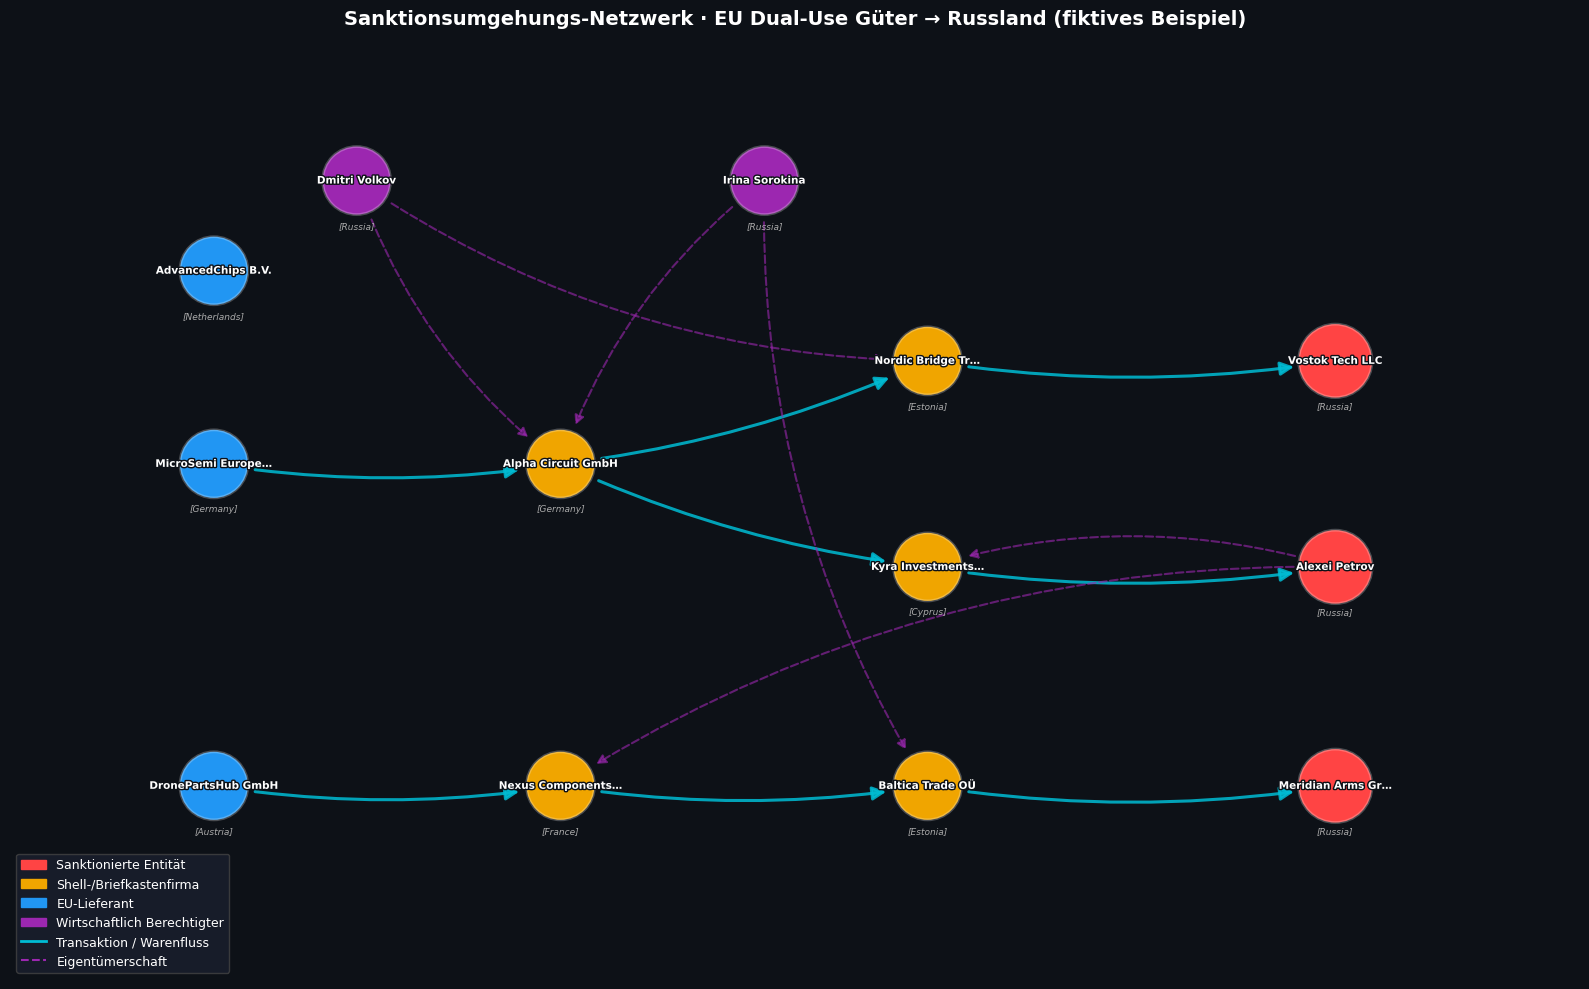


✅ Graph-Visualisierung abgeschlossen.


In [ ]:
# ─── Netzwerk aus Neo4j in networkx laden & visualisieren ─────────────────────
G = nx.DiGraph()
node_attrs = {}

with driver.session() as session:
    # Alle Knoten
    for row in session.run("MATCH (n:Entity) RETURN n").data():
        n = row["n"]
        G.add_node(n["id"], **dict(n))
        node_attrs[n["id"]] = dict(n)

    # Alle Kanten (Transaktionen + Eigentümerschaft)
    for row in session.run("""
        MATCH (a:Entity)-[r:TRANSFERRED_TO|OWNS]->(b:Entity)
        RETURN a.id AS src, type(r) AS rel_type, b.id AS tgt,
               r.amount AS amount, r.share_pct AS share_pct
    """).data():
        G.add_edge(row["src"], row["tgt"],
                   rel=row["rel_type"],
                   amount=row.get("amount", 0),
                   share_pct=row.get("share_pct", 0))

# ─── Layout & Farben ──────────────────────────────────────────────────────────
pos = {
    "SUP001": (-3.5,  0.0),  "SUP002": (-3.5, -2.5), "SUP003": (-3.5,  1.5),
    "SH002":  (-1.8,  0.0),  "SH004":  (-1.8, -2.5),
    "SH001":  ( 0.0,  0.8),  "SH003":  ( 0.0, -2.5), "SH005":  ( 0.0, -0.8),
    "SE001":  ( 2.0,  0.8),  "SE003":  ( 2.0, -2.5), "SE002":  ( 2.0, -0.8),
    "BO001":  (-2.8,  2.2),  "BO002":  (-0.8,  2.2),
}

def node_color(nid):
    n = node_attrs.get(nid, {})
    if n.get("sanctioned"):  return "#ff4444"
    if nid.startswith("SH"): return "#f0a500"
    if nid.startswith("SUP"):return "#2196f3"
    return "#9c27b0"

fig, ax = plt.subplots(figsize=(16, 10), facecolor="#0d1117")
ax.set_facecolor("#0d1117")

colors = [node_color(n) for n in G.nodes()]
sizes  = [2800 if node_attrs.get(n,{}).get("sanctioned") else 2400 for n in G.nodes()]

tx_edges  = [(u,v) for u,v,d in G.edges(data=True) if d["rel"]=="TRANSFERRED_TO"]
own_edges = [(u,v) for u,v,d in G.edges(data=True) if d["rel"]=="OWNS"]

nx.draw_networkx_edges(G, pos, edgelist=tx_edges, ax=ax,
    edge_color="#00bcd4", width=2.2, alpha=0.85, arrows=True, arrowsize=20,
    connectionstyle="arc3,rad=0.08",
    min_source_margin=30, min_target_margin=30)
nx.draw_networkx_edges(G, pos, edgelist=own_edges, ax=ax,
    edge_color="#9c27b0", width=1.5, alpha=0.6, arrows=True, arrowsize=14,
    style="dashed", connectionstyle="arc3,rad=0.15",
    min_source_margin=30, min_target_margin=30)
nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=colors, node_size=sizes,
    linewidths=2, edgecolors="#ffffff40")

for nid, (x, y) in pos.items():
    name = node_attrs.get(nid, {}).get("name", nid)
    short = name if len(name) <= 18 else name[:16] + "…"
    ax.text(x, y,     short,  ha="center", va="center",
            fontsize=7.5, fontweight="bold", color="white",
            path_effects=[pe.withStroke(linewidth=2, foreground="#0d1117")])
    ax.text(x, y-0.35, f"[{node_attrs.get(nid,{}).get('country','')}]",
            ha="center", va="center", fontsize=6.5, color="#aaaaaa", style="italic")

ax.set_title(
    "Sanktionsumgehungs-Netzwerk · EU Dual-Use Güter → Russland (fiktives Beispiel)",
    fontsize=14, color="white", pad=20, fontweight="bold")

legend = [
    mpatches.Patch(color="#ff4444", label="Sanktionierte Entität"),
    mpatches.Patch(color="#f0a500", label="Shell-/Briefkastenfirma"),
    mpatches.Patch(color="#2196f3", label="EU-Lieferant"),
    mpatches.Patch(color="#9c27b0", label="Wirtschaftlich Berechtigter"),
    plt.Line2D([0],[0], color="#00bcd4", lw=2,    label="Transaktion / Warenfluss"),
    plt.Line2D([0],[0], color="#9c27b0", lw=1.5,  linestyle="--", label="Eigentümerschaft"),
]
ax.legend(handles=legend, loc="lower left",
          facecolor="#1a1f2e", edgecolor="#444", labelcolor="white", fontsize=9)
ax.axis("off")
ax.set_xlim(-4.5, 3.2); ax.set_ylim(-4.0, 3.2)
plt.tight_layout()
plt.show()
print("\n✅ Graph-Visualisierung abgeschlossen.")


---
## Ergebnis

Mit vier schrittweise aufbauenden Cypher-Queries haben wir:

1. **Direkte** Transaktionen zu sanktionierten Entitäten identifiziert
2. EU-Shell-Firmen unter **russischer Kontrolle** aufgedeckt
3. Den **Geldfluss** von sanktionierten Personen über ihre Offshore-Shells nachverfolgt
4. **Vollständige Lieferkettenpfade** vom legitimen EU-Lieferanten bis zum sanktionierten Endempfänger gefunden

> Neo4j hat in wenigen Millisekunden Pfade aufgedeckt, die in klassischen  
> SQL-Systemen aufwändige Multi-Table-Joins mit CTEs erfordern würden —  
> und die in Tabellen-Sichten kaum intuitiv erfassbar wären.

### Weiterführende Ressourcen
- [Neo4j Graph Data Science Library](https://neo4j.com/docs/graph-data-science/current/)
- [ICIJ Offshore Leaks Database](https://offshoreleaks.icij.org/)
- [OpenSanctions.org](https://www.opensanctions.org/)
- [FATF Recommendations](https://www.fatf-gafi.org/en/topics/fatf-recommendations.html)
